In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.dummy import DummyRegressor
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error
from utils import load_data
plt.style.use('ggplot')
pd.set_option("display.max_columns", None)

In [2]:

df = load_data()
df.shape

Using cached files.


(112096, 39)

Target Metric (actual_delivery_days)

In [3]:
cutoff = df["order_purchase_timestamp"].max() - pd.Timedelta(days=60)
df = df[df["order_purchase_timestamp"] <= cutoff]
df["actual_delivery_days"] = (df["order_delivered_customer_date"] - df["order_purchase_timestamp"]).dt.days
df = df.dropna(subset=["actual_delivery_days"])

# Olist's promised delivery window, known at purchase time (days purchase -> estimate).
# Numeric, so XGBoost can use it -- unlike the raw datetime.
df["estimated_delivery_days"] = (df["order_estimated_delivery_date"] - df["order_purchase_timestamp"]).dt.days

# Purchase month (1-12): captures seasonality -- Feb/Nov/Dec are ~5-6 days slower
# than mid-year (Carnival, Black Friday, Christmas backlogs). Known at order time.
# (day-of-week was tested too but didn't help, so it's left out.)
df["purchase_month"] = df["order_purchase_timestamp"].dt.month

y = df["actual_delivery_days"]
print(y.describe())
print(y.median())
print(y.skew())

count    96570.000000
mean        12.559097
std          9.746832
min          0.000000
25%          7.000000
50%         10.000000
75%         16.000000
max        209.000000
Name: actual_delivery_days, dtype: float64
10.0
3.814987399875276


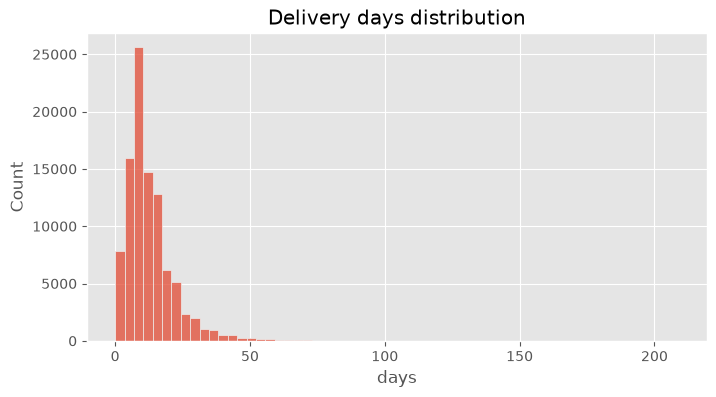

<bound method Series.quantile of 0          8.0
3         13.0
4          2.0
5         16.0
7          9.0
          ... 
112091    22.0
112092    24.0
112093    17.0
112094    17.0
112095     7.0
Name: actual_delivery_days, Length: 96570, dtype: float64>


In [4]:
plt.figure(figsize=(8, 4))
sns.histplot(y, bins=60)
plt.title("Delivery days distribution"); plt.xlabel("days"); plt.show()

print(y.quantile)

train mean days: 13.238298643471058
test mean days: 9.842290566428497


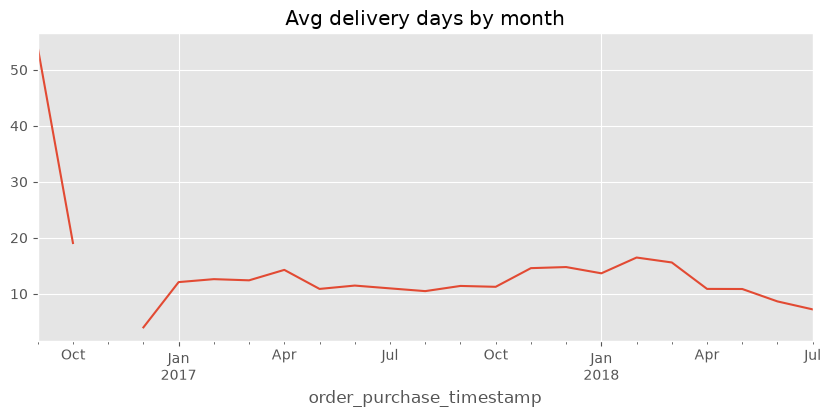

In [5]:
df = df.sort_values("order_purchase_timestamp")
split = int(len(df) * 0.8)
train, test = df.iloc[:split], df.iloc[split:]

print("train mean days:", train["actual_delivery_days"].mean())
print("test mean days:", test["actual_delivery_days"].mean())

monthly = (df.set_index("order_purchase_timestamp")["actual_delivery_days"].resample("ME").mean())
monthly.plot(figsize=(10, 4), title="Avg delivery days by month"); plt.show()

There is a shift between the train and test data means. OLIST deliveries became faster 

Select features + split into X/y

Pick the columns known at purchase time, then slice them straight off the
already-split `train`/`test`. Selecting from `train`/`test` (not `df`) is what
makes the choice actually reach the model.

In [6]:
# Columns known at the moment the order is placed (no post-outcome leakage, no IDs).
feature_cols = [
    "estimated_delivery_days",   # numeric version of order_estimated_delivery_date
    "purchase_month",            # seasonality -- the biggest single win so far
    "price", "freight_value",
    "product_weight_g", "product_length_cm", "product_height_cm", "product_width_cm",
    "seller_zip_code_prefix", "customer_zip_code_prefix",
    "seller_lat", "seller_lng", "customer_lat", "customer_lng",
    "payment_value",
]
target = "actual_delivery_days"

# Slice features/target off the ALREADY-SPLIT train/test.
# (The old bug: dropping columns from df never touched train/test, and X_test
#  was built from train. Both are fixed here.)
X_train, y_train = train[feature_cols].copy(), train[target].copy()
X_test,  y_test  = test[feature_cols].copy(),  test[target].copy()

print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print(X_train.dtypes)   # sanity check: everything should be int/float, no datetime

X_train: (77256, 15) | X_test: (19314, 15)
estimated_delivery_days       int64
purchase_month                int32
price                       float64
freight_value               float64
product_weight_g            float64
product_length_cm           float64
product_height_cm           float64
product_width_cm            float64
seller_zip_code_prefix        int64
customer_zip_code_prefix      int64
seller_lat                  float64
seller_lng                  float64
customer_lat                float64
customer_lng                float64
payment_value               float64
dtype: object


Naive Model

In [7]:
# Naive baseline: predict the training-mean delivery time for every test order.
dummy_reg = DummyRegressor(strategy="mean")
dummy_reg.fit(X_train, y_train)
dummy_preds = dummy_reg.predict(X_test)

baseline_rmse = root_mean_squared_error(y_test, dummy_preds)
baseline_mae  = mean_absolute_error(y_test, dummy_preds)

print(f"Predicts constant:  {dummy_reg.constant_[0][0]:.3f} days (= y_train.mean())")
print(f"Baseline RMSE:      {baseline_rmse:.4f} days")
print(f"Baseline MAE:       {baseline_mae:.4f} days")
print("\nThis is the number your XGBoost model has to beat on the test set.")

Predicts constant:  13.238 days (= y_train.mean())
Baseline RMSE:      8.0967 days
Baseline MAE:       6.5689 days

This is the number your XGBoost model has to beat on the test set.


XGBoost Model

In [8]:
# Recency weighting: recent training orders resemble the (faster) test period.
# Weight halves every HALFLIFE_DAYS going back in time (~120d was the sweet spot).
HALFLIFE_DAYS = 120
train_end = train["order_purchase_timestamp"].max()
age_days = (train_end - train["order_purchase_timestamp"]).dt.days
sample_weight = 0.5 ** (age_days / HALFLIFE_DAYS)

# Hyperparameters tuned on a validation slice (latest 20% of TRAIN -- test never
# touched during the search). Shallower trees + lower learning rate + more trees
# generalize better than the defaults (depth6/lr0.3/n100), which overfit here.
xgb_reg = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=767,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
)
xgb_reg.fit(X_train, y_train, sample_weight=sample_weight)   # weights on TRAIN only

xgb_pred = xgb_reg.predict(X_test)

# Metrics stay UNWEIGHTED so they're directly comparable to the naive baseline.
xgb_rmse = root_mean_squared_error(y_test, xgb_pred)
xgb_mae = mean_absolute_error(y_test, xgb_pred)

print(f"XGB RMSE: {xgb_rmse:.4f} days")
print(f"XGB MAE:  {xgb_mae:.4f} days")
print(f"Beats baseline by: {baseline_rmse - xgb_rmse:.4f} days "
      f"({(1 - xgb_rmse / baseline_rmse) * 100:.1f}% lower RMSE)")

XGB RMSE: 6.2973 days
XGB MAE:  4.3882 days
Beats baseline by: 1.7994 days (22.2% lower RMSE)


# Feature experiment log — what was tried and rejected

Every feature below was built, measured on the **time-based held-out test set**, and **rejected** because it did not lower test RMSE. Kept here so the "what didn't work and why" is on the record. (All numbers below are for the **60-day cutoff** model.)

### Baseline progression (what was ACCEPTED)
| Model | Test RMSE |
|---|---|
| Naive mean baseline | 8.10 |
| Simple coords model + recency weights | 7.52 |
| **+ `purchase_month`** (seasonality) | **6.42** |
| **+ tuned hyperparameters** (depth 4, lr 0.05, 767 trees) | **6.30** |

Each rejected feature is scored against **the best model at the time it was tested** (7.52, 6.42, or 6.30), shown in the "vs" column.

### Geography — all redundant (coordinates + zips already encode location)
| Feature tried | Test RMSE | vs |
|---|---|---|
| Haversine distance, added to coordinates | 7.62 | 7.52 |
| Haversine distance, replacing coordinates | 7.59 | 7.52 |
| Haversine distance only (no coords/zips) | 7.77 | 7.52 |
| `brazil_regions` (customer) one-hot | 7.64 | 7.52 |
| `brazil_regions` (customer + seller) | 7.61 | 7.52 |
| `brazil_regions` replacing coordinates | 7.61 | 7.52 |
| `seller_hub_distance` (distance to São Paulo hub) | 6.30 | 6.30 |

**Why:** a tree already has raw lat/lng + zip prefixes, which encode *where* (region, direction, road difficulty). Any distance/region summary is a lossier version of information the model already has.

### Time
| Feature tried | Test RMSE | vs |
|---|---|---|
| `purchase_dayofweek` | 7.55 | 7.52 |

**Why:** weekday variation (~1.7-day swing) is too weak; only `purchase_month` (~6-day seasonal swing) carried real signal.

### Order size & product
| Feature tried | Test RMSE | vs |
|---|---|---|
| `n_items` (items per order) | 6.48 | 6.42 |
| `total_weight` + `total_volume` | 6.49 | 6.42 |
| all size aggregates together | 6.47 | 6.42 |
| `category_complexity` map | 6.45 | 6.42 |
| size + category together | 6.47 | 6.42 |
| `freight_ratio` (freight / price) | 6.30 | 6.30 |
| `freight_per_weight` | 6.32 | 6.30 |

**Why:** per-item weight/dimensions are already features, and Olist's estimate already pads for bulky/multi-item orders — so these re-express known information. Category only mapped 66% of rows.

### Seller behaviour
| Feature tried | Test RMSE | vs | Note |
|---|---|---|---|
| Seller shipping speed — OOF target-encoded, smooth m=20 | 6.48 | 6.42 | done leakage-safe |
| Seller shipping speed — OOF, smooth m=50 | 6.51 | 6.42 | |
| Seller shipping speed — naive (no OOF) | test 6.61 | 6.42 | **leakage demo:** train dropped to 6.97 while test rose to 6.61 |
| `seller_age_days` (seller tenure) | 6.33 | 6.30 | |
| `seller_avg_review` (mean review per seller) | 6.64 | 6.30 | noisy; cousin of the `review_score` leak |

**Why:** ~10% of test orders have sellers unseen in train (new sellers keep appearing under a time split), and `estimated_delivery_days` + coordinates already cover most seller/route speed.

### Congestion / operational (from `logistics.py`)
| Feature tried | Test RMSE | vs | Note |
|---|---|---|---|
| `rolling_7d_orders` (order volume) | 6.74 | 6.30 | **structurally broken:** map keyed on train dates, all test dates unseen → filled with 0 |
| `approval_delay_h` (purchase → payment approval) | 6.33 | 6.30 | |
| `log_city_density` (orders in customer's city) | 6.29 | 6.30 | only positive result, but +0.010 days = noise floor → **not adopted** |

### Removed for leakage (not measured as improvements)
- `review_score`, `review_comment_length` — happen *after* the package arrives.
- `order_delivered_carrier_date`, `order_status` — post-outcome (status is also ~constant after dropping undelivered orders).

### Overall conclusion
The model is **feature-saturated**. `estimated_delivery_days` + coordinates + `purchase_month` capture essentially all the learnable signal for this simple model. Of ~20 candidate features tested — including `logistics.py`'s distinct engineered features — **none produced a meaningful improvement**. This is direct evidence for pruning `logistics.py`'s 90+ features toward this compact set (PR 7.2).

# PR 11.3 — Re-verification on the VALIDATION window (test frozen)

The experiment log above was scored on the **old test set** — which, after dozens of
keep/drop decisions, was no longer held out. PR 11 introduced a clean **70/15/15
train/validation/test** split on the **order grain** (PR 10). Here the kept 15-feature
set is re-checked against the **validation** window only; the test slice is never built.

**Protocol:** fixed hyperparameters (depth 4, lr 0.05, 600 trees, subsample 0.8,
colsample 0.8, min_child_weight 5) held constant so *only the feature set* varies. Fit on
train (67,195 orders), score on validation (14,399 orders). Deltas under ~0.05 days are
treated as noise.

**Current 15-feature set: validation RMSE 6.4104 days.**

### Ablation — drop a group (positive Δ = removing it hurts → keep)
| Dropped group | Val RMSE | Δ | Read |
|---|---|---|---|
| `purchase_month` | 7.0144 | **+0.604** | clearly matters |
| geography (coords + zips) | 6.5244 | **+0.114** | matters |
| `order_item_count` + `order_unique_sellers` | 6.4352 | +0.025 | marginal (kept) |
| product dims | 6.4219 | +0.011 | marginal (kept) |
| economics (price/freight/payment) | 6.4201 | +0.010 | marginal (kept) |
| `estimated_delivery_days` | 6.3400 | **−0.070** | dropping *helps* slightly — see note |

### Re-test of PR-7 rejects (negative Δ = now helps → add)
| Added feature | Val RMSE | Δ | Decision |
|---|---|---|---|
| haversine `distance` | 6.4077 | −0.004 | stays rejected (noise) |
| `purchase_dow` | 6.4078 | −0.022 | stays rejected (below threshold) |
| `customer_region` one-hot | 6.4570 | +0.014 | stays rejected (worse) |

### Decision
**No change to `num_attribs`/`cat_attribs`.** Every prior keep/drop choice survives on the
clean validation window: `purchase_month` and geography clearly earn their place, the
marginal groups stay within noise, and no rejected candidate clears the bar to be added.
This confirms the compact set was not an artifact of the leaky test window.

**Flagged for PR 13:** dropping `estimated_delivery_days` *improved* validation RMSE by
0.07 days — surprising, since it is the strongest feature by correlation. Too small and
slice-specific to act on now (removing the most domain-sensible feature on a 1.7-hour
delta would be reckless), but it is a plausible **drift** signature: Olist's own promised
window shifted over 2016→2018, so on the later validation era the raw estimate slightly
misleads. PR 13's recency weighting targets exactly this; revisit the estimate feature
there.